# Python for Data Science

The jupyter notebook can be viewed through nbviewer at this link: https://nbviewer.org/github/Skycr/skill-assessments/blob/main/Python%20for%20Data%20Science/datascience_miniproject.ipynb

In [1]:
import statistics
from scipy import stats
import plotly.express as px
import pandas as pd

## Part 1

### 1. Read the gapminder_clean.csv data as Pandas Dataframe

In [2]:
# read dataset as a pandas dataframe
df = pd.read_csv("gapminder_clean.csv", index_col=0)

### 2. Filter the data to include only rows where Year is 1962 and then make a scatter plot comparing 'CO" emissions (metric tons per capita)' and gdpPercap for the filtered data.

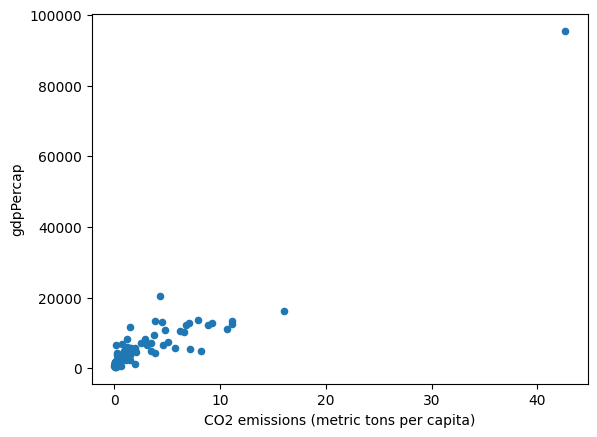

In [3]:
# filter rows to only include rows with the year 1962
filtered_df = df[df["Year"] == 1962]
# scatter plot of CO2 emissions and gdp per capita
ax1 = filtered_df.plot.scatter(
    x="CO2 emissions (metric tons per capita)", y="gdpPercap"
)

### 3. On the filtered data, calculate the correlation of 'CO2 emissions (metric tons per capita) and gdpPercap. What is the correlation and associated p value?

In [4]:
# on the filtered data, include only CO2 emissions and gdp per capita columns
filtered_df = filtered_df.filter(
    items=[
        "CO2 emissions (metric tons per capita)",
        "gdpPercap",
    ]
)
# filter any rows with missing values
new_df = filtered_df.dropna()
# test correlation and p-value between CO2 emissions and gdp per capita
stats.pearsonr(new_df["CO2 emissions (metric tons per capita)"], new_df["gdpPercap"])

PearsonRResult(statistic=np.float64(0.9260816725019473), pvalue=np.float64(1.1286792210037025e-46))

### 4. On the unfiltered data, answer "In what year is the correlation between 'CO2 emissions (metric tons per capita)' and gdpPercap the strongest?" Filter the dataset to that year for the next step...

In [5]:
# year in which correlation between CO2 emissions and gdp per capita is strongest
year_lst = df["Year"].unique()
flst = []
# calculate correlation for each year in for loop and append result to list
for year in year_lst:
    tdf = df[df["Year"] == year]
    tdf = tdf.filter(
        items=["Year", "CO2 emissions (metric tons per capita)", "gdpPercap"]
    )
    tdf = tdf.dropna()
    results = stats.pearsonr(
        tdf["CO2 emissions (metric tons per capita)"], tdf["gdpPercap"]
    )
    flst.append([int(year), results])

# sort results by highest correlation in ascending order
a = sorted(flst, key=lambda x: x[1], reverse=True)
# #extract year with highest correlation
a[0]

[1967,
 PearsonRResult(statistic=np.float64(0.938791838506331), pvalue=np.float64(3.3971433566412762e-53))]

### 5. Using plotly or bokeh, create an interactive scatter plot comparing 'CO2 emissions (metric tons per capita)' and gdpPercap, where the point size is determined by pop (population) and the color is determined by the continent.

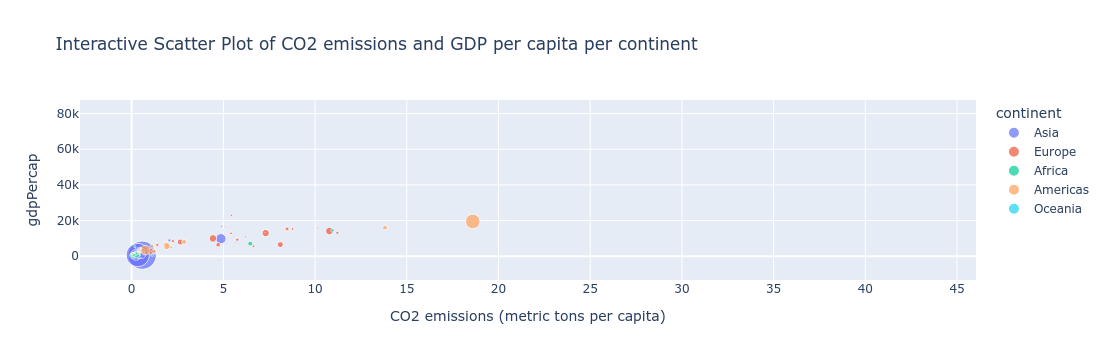

In [6]:
# filter rows to only include rows with the year with highest correlation
new_filtered = df[df["Year"] == a[0][0]]

# create interactive scatter plot
fig = px.scatter(
    new_filtered,
    title="Interactive Scatter Plot of CO2 emissions and GDP per capita per continent",
    x="CO2 emissions (metric tons per capita)",
    y="gdpPercap",
    size="pop",
    color="continent",
)
fig.show()

## Part 2

### 1. What is the relationship between continent and 'Energy use (kg of oil equivalent per capita)'? (Stats test needed)

A one-way ANOVA test was used to compare the means of a single independant variable (Energy use (kg of oil equivalent per capita)) across five categorical groups, in this case between the major continents. Additionally, only one quantitative variable is expected as the final outcome.

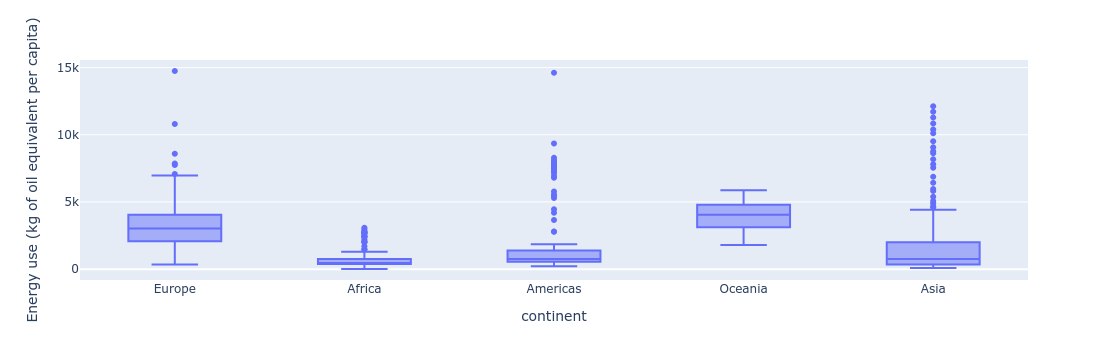

F_onewayResult(statistic=np.float64(51.459157590426344), pvalue=np.float64(8.527003487154367e-39))

In [7]:
# filter by relevant variables
adf = df.filter(
    items=["Year", "continent", "Energy use (kg of oil equivalent per capita)"]
)
# remove rows with missing values
adf = adf.dropna()
# create dictionary of continents and energy use per capita
groups = (
    adf.groupby("continent")["Energy use (kg of oil equivalent per capita)"]
    .apply(list)
    .to_dict()
)
# create box plots to visualised variation within each continent
fig = px.box(adf, x="continent", y="Energy use (kg of oil equivalent per capita)")
fig.show()
# perform anova
stats.f_oneway(
    groups["Europe"],
    groups["Africa"],
    groups["Americas"],
    groups["Oceania"],
    groups["Asia"],
)

### 2. Is there a significant difference between Europe and Asia with respect to 'Imports of goods and services (% of GDP)' in the years after 1990? (Stats test needed)

A t-test was used as there are only two categorical groups are being compared, with only one outcome variable being expected

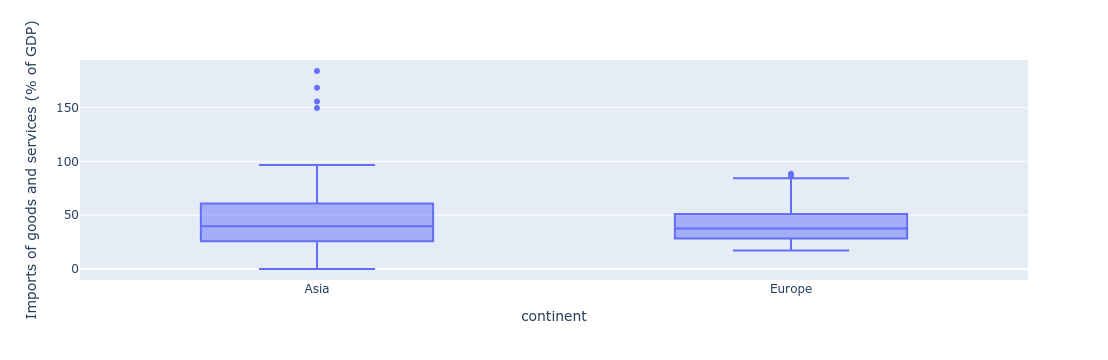

TtestResult(statistic=np.float64(-1.4185256887958868), pvalue=np.float64(0.15751969325554196), df=np.float64(210.0))

In [8]:
# filter by relevant variables
tdf = df.filter(items=["Year", "continent", "Imports of goods and services (% of GDP)"])
tdf = tdf[tdf["Year"] > 1990]
# remove rows with missing values
tdf = tdf.dropna()
# visualise variation
tdf = tdf[(tdf["continent"] == "Europe") | (tdf["continent"] == "Asia")]
tfig = px.box(tdf, x="continent", y="Imports of goods and services (% of GDP)")
tfig.show()
# t-test
groups = (
    tdf.groupby("continent")["Imports of goods and services (% of GDP)"]
    .apply(list)
    .to_dict()
)
stats.ttest_ind(groups["Europe"], groups["Asia"])

### 3. What is the country (or countries) that has the highest 'Population density (people per sq. km of land area)' across all years? (i.e., which country has the highest average ranking in this category across each time point in the dataset?)

In [9]:
# filter by relevant variables
rdf = df.filter(
    items=[
        "Year",
        "Country Name",
        "Population density (people per sq. km of land area)",
    ]
)
# remove rows with missing values
rdf = rdf.dropna()
# create dictionary of countries pop densities across all years
groups = (
    rdf.groupby("Country Name")["Population density (people per sq. km of land area)"]
    .apply(list)
    .to_dict()
)
country_lst = rdf["Country Name"].unique()
yr_lst = rdf["Year"].unique()
clst = []
# calculate mean of pop densities for each country across all years
for country in country_lst:
    clst.append([country, statistics.mean(groups[country])])

rdf.sort_values(
    by=["Population density (people per sq. km of land area)"], ascending=False
)
rdf.groupby(by=["Year"])["Population density (people per sq. km of land area)"].max()

# sort resulting list by value of the mean of population density in ascending order
c = sorted(clst, key=lambda x: x[1], reverse=True)
c[0]

['Macao SAR, China', 14732.03521055]

In [128]:
# calculate highest pop density for each year
elst = []
for yr in yr_lst:
    subset = (
        rdf[rdf["Year"] == yr]
        .sort_values(
            by=["Population density (people per sq. km of land area)"], ascending=False
        )
        .iloc[[0]]
    )
    elst.append(subset)

final = pd.concat(elst, ignore_index=True)
final

,Year,Country Name,Population density (people per sq. km of land area)
0,1962,Monaco,11521.000000
1,1967,Monaco,11648.500000
2,1972,"Macao SAR, China",12714.100000
3,1977,Monaco,12904.500000
4,1982,Monaco,13814.500000
5,1987,"Macao SAR, China",16132.750000
6,1992,"Macao SAR, China",18889.950000
7,1997,"Macao SAR, China",20601.550000
8,2002,"Macao SAR, China",16451.037037
9,2007,Monaco,17523.000000


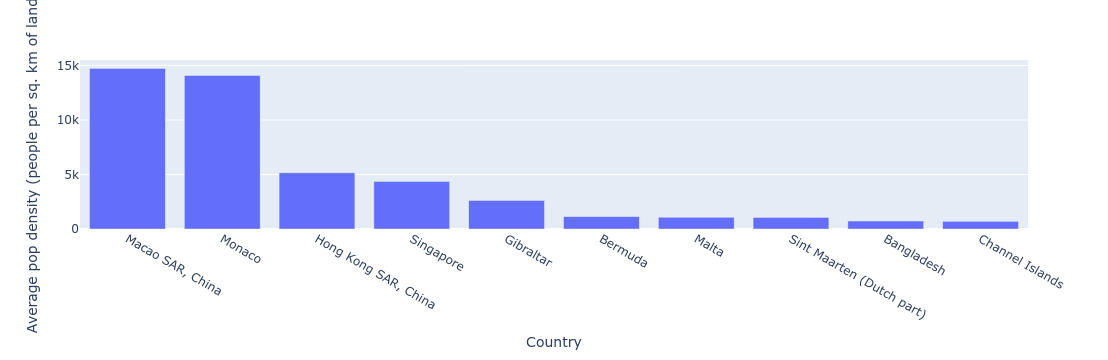

In [129]:
# visualize results with bar plots to show countries with the highest average populution density
r = pd.DataFrame(
    c, columns=["Country", "Average pop density (people per sq. km of land area)"]
)
fig = px.bar(
    r[:10], x="Country", y="Average pop density (people per sq. km of land area)"
)
fig.show()

### 4. What country (or countries) has shown the greatest increase in 'Life expectancy at birth, total (years)' between 1962 and 2007?

In [130]:
# filter by relevant variables
ldf = df.filter(
    items=["Country Name", "Year", "Life expectancy at birth, total (years)"]
)
# filter to include only rows where year is 2007
ldf = ldf[ldf["Year"] == 2007]
# remove rows with missing values
ldf = ldf.dropna()
# create dictionary where keys are country name and values are life expectancy in 2007
ldf_dict = ldf.set_index("Country Name")[
    "Life expectancy at birth, total (years)"
].to_dict()

# filter by relevant variables
edf = df.filter(
    items=["Country Name", "Year", "Life expectancy at birth, total (years)"]
)
# filter to include only rows where year is 1962
edf = edf[edf["Year"] == 1962]
# remove rows with missing values
edf = edf.dropna()
# create list of country names and life expectancy in 1962 within a list
result = edf[
    ["Country Name", "Life expectancy at birth, total (years)"]
].values.tolist()

# for loop to calculate the difference of life between 1962 and 2007 for each country
life_ex_lst = []
for r in result:
    if r[0] in ldf_dict:
        life_ex_lst.append([r[0], ldf_dict[r[0]] - r[1]])

# sort resulting list by the value of life expectancy difference in ascending order
life_ex_lst = sorted(life_ex_lst, key=lambda x: x[1], reverse=True)
life_ex_lst[0]

['Maldives', 36.916146341499996]

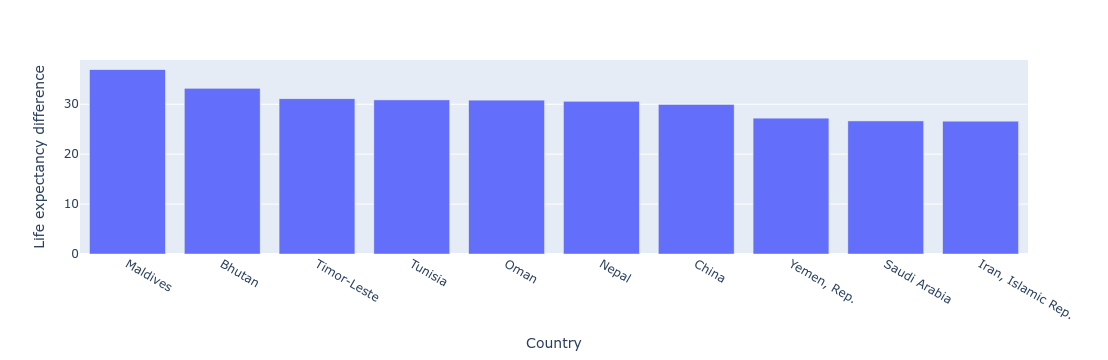

In [131]:
# visualise results with bar plots to countries with highest increase in life expectancy
life_ex_lst
l = pd.DataFrame(life_ex_lst, columns=["Country", "Life expectancy difference"])
fig = px.bar(l[:10], x="Country", y="Life expectancy difference")
fig.show()